I072 Yashvi Shah
I058 shobit shah

dataset links:
1. 50K IMDB REVIEWS: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

2. Rotten Tomatoes: https://www.kaggle.com/datasets/mrbaloglu/rotten-tomatoes-reviews-dataset

#imports

In [1]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [2]:
import os
import json

from zipfile import ZipFile
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import re

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib import style
style.use('ggplot')
import re
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
import nltk
nltk.download('stopwords')
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#Data Fetch

In [3]:
!pip install kaggle

**Data Collection- Kaggle API**

In [4]:
import kagglehub

path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

100%|██████████| 25.7M/25.7M [00:00<00:00, 70.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1


In [17]:
kaggle_dictionary = json.load(open("kaggle.json"))

In [18]:
kaggle_dictionary.keys()

dict_keys(['username', 'key'])

In [19]:
# setup kaggle credentials as environment variables
os.environ["KAGGLE_USERNAME"] = kaggle_dictionary["username"]
os.environ["KAGGLE_KEY"] = kaggle_dictionary["key"]

In [20]:
!kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
License(s): other
  0% 0.00/25.7M [00:00<?, ?B/s]
100% 25.7M/25.7M [00:00<00:00, 291MB/s]


In [21]:
!ls

imdb-dataset-of-50k-movie-reviews.zip  kaggle.json  my_dir  sample_data


In [22]:
# unzip the dataset file
with ZipFile("imdb-dataset-of-50k-movie-reviews.zip", "r") as zip_ref:
  zip_ref.extractall()

In [23]:
!ls

'IMDB Dataset.csv'   imdb-dataset-of-50k-movie-reviews.zip   kaggle.json   my_dir   sample_data


#load data

In [24]:
data = pd.read_csv("/content/IMDB Dataset.csv")

In [25]:
data

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [26]:
data.review[0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [27]:

data.replace({"sentiment": {"positive": 1, "negative": 0}}, inplace=True)

<ipython-input-27-c1a779bd745a>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({"sentiment": {"positive": 1, "negative": 0}}, inplace=True)


#preproccess

In [28]:
def data_processing(text):
    text = text.lower()
    text = re.sub('<br />', '', text)#br tags
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)#https and all that stuff
    text = re.sub(r'\@w+|\#','', text)#username,hashtags
    text = re.sub(r'[^\w\s]','', text)#wgitespace punct
    text_tokens = word_tokenize(text)
    filtered_text = [w for w in text_tokens if not w in stop_words]  #Filters out stop word
     #Joins the filtered words back into a single string, with each word separated by a space, and returns the processed text.
    return " ".join(filtered_text)

In [29]:
data.review = data['review'].apply(data_processing)

In [30]:
stemmer = PorterStemmer()
def stemming(data):
    text = [stemmer.stem(word) for word in data]
    return data

In [31]:
data.review = data['review'].apply(lambda x: stemming(x))

In [32]:
data.review[0]

'one reviewers mentioned watching 1 oz episode youll hooked right exactly happened methe first thing struck oz brutality unflinching scenes violence set right word go trust show faint hearted timid show pulls punches regards drugs sex violence hardcore classic use wordit called oz nickname given oswald maximum security state penitentary focuses mainly emerald city experimental section prison cells glass fronts face inwards privacy high agenda em city home manyaryans muslims gangstas latinos christians italians irish moreso scuffles death stares dodgy dealings shady agreements never far awayi would say main appeal show due fact goes shows wouldnt dare forget pretty pictures painted mainstream audiences forget charm forget romanceoz doesnt mess around first episode ever saw struck nasty surreal couldnt say ready watched developed taste oz got accustomed high levels graphic violence violence injustice crooked guards wholl sold nickel inmates wholl kill order get away well mannered middle 

In [33]:
# split data into training data and test data
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

In [34]:
X_train = train_data['review']
y_train = train_data['sentiment']
X_test = test_data['review']
y_test = test_data['sentiment']

In [35]:
#Y_train = train_data["sentiment"]
#Y_test = test_data["sentiment"]

In [36]:
#Tokenization
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)
x_train_seq = tokenizer.texts_to_sequences(X_train)
x_test_seq = tokenizer.texts_to_sequences(X_test)

In [37]:
#Padding sequences
x_train = pad_sequences(x_train_seq, maxlen=200)
x_test = pad_sequences(x_test_seq, maxlen=200)

#eda

In [ ]:
data.shape

(50000, 2)

In [ ]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
data.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [ ]:
sentiment_counts = data["sentiment"].value_counts()
print(sentiment_counts)

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


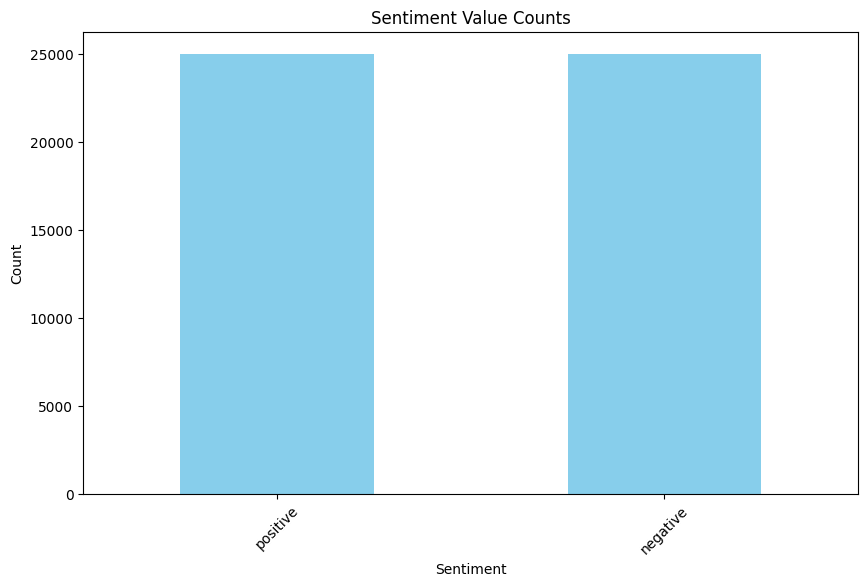

In [ ]:
plt.figure(figsize=(10, 6))
sentiment_counts.plot(kind='bar', color='skyblue')
plt.title('Sentiment Value Counts')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

replacing pos n neg with 1 and 0 resp

In [ ]:
data.replace({"sentiment": {"positive": 1, "negative": 0}}, inplace=True)

<ipython-input-29-c1a779bd745a>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({"sentiment": {"positive": 1, "negative": 0}}, inplace=True)


In [ ]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [ ]:
data["sentiment"].value_counts()

,count
sentiment,
1,25000
0,25000


most freq words in pos review

In [ ]:
pos_reviews = data[data.sentiment ==1]
pos_reviews.head()

,review,sentiment
0,one reviewers mentioned watching 1 oz episode ...,1
1,wonderful little production filming technique ...,1
2,thought wonderful way spend time hot summer we...,1
4,petter matteis love time money visually stunni...,1
5,probably alltime favorite movie story selfless...,1


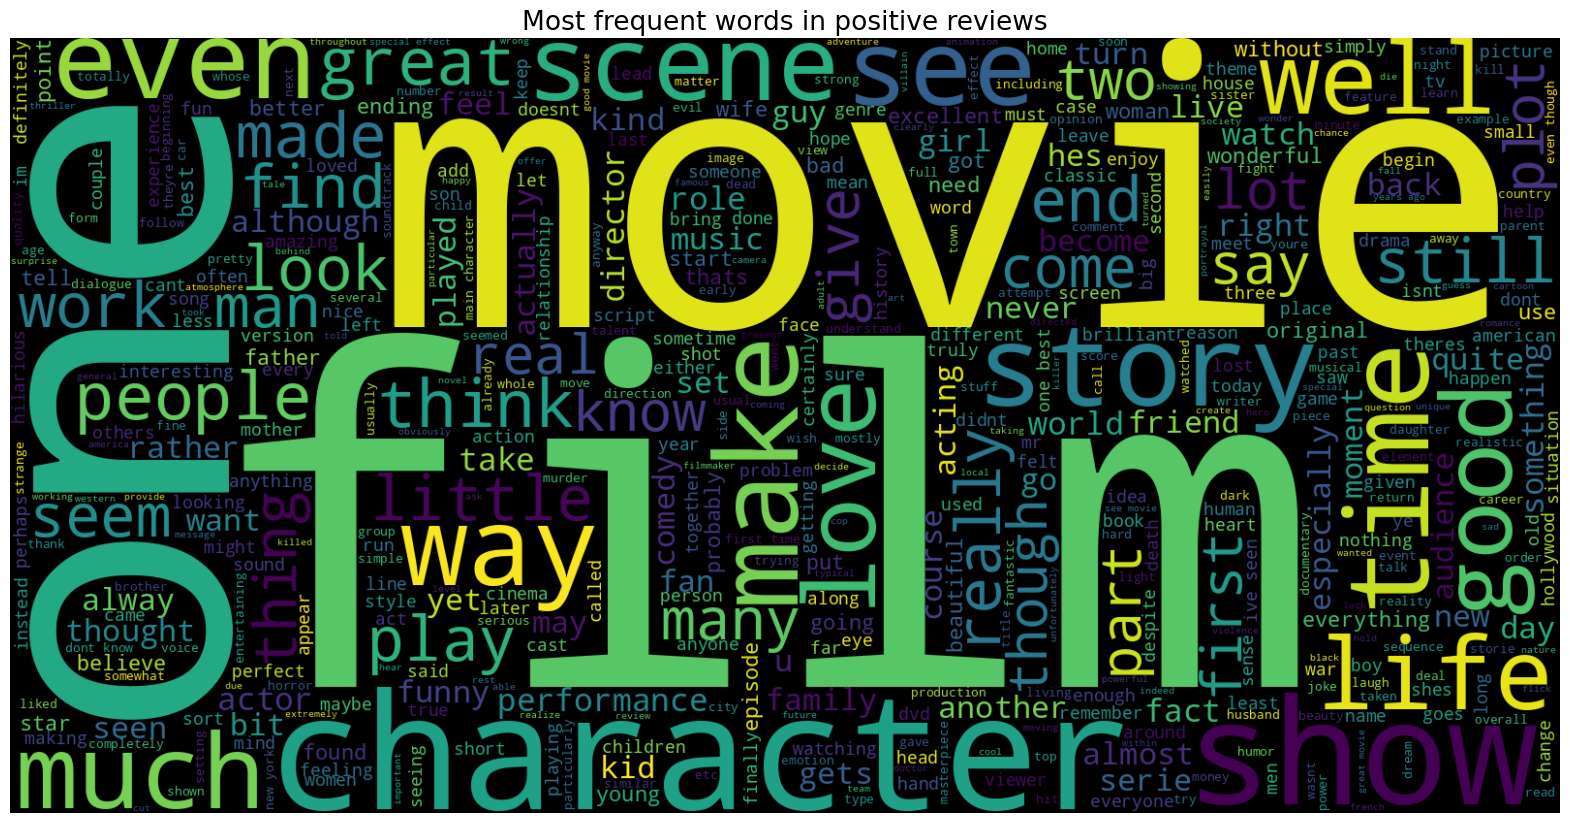

In [ ]:
text = ' '.join([word for word in pos_reviews['review']])
plt.figure(figsize=(20,15), facecolor='None')
wordcloud = WordCloud(max_words=500, width=1600, height=800).generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title('Most frequent words in positive reviews', fontsize = 19)
plt.show()

In [ ]:
from collections import Counter
count = Counter()
for text in pos_reviews['review'].values:
    for word in text.split():
        count[word] +=1
count.most_common(15)

[('film', 39419),
 ('movie', 36019),
 ('one', 25730),
 ('like', 17055),
 ('good', 14342),
 ('great', 12643),
 ('story', 12372),
 ('see', 11865),
 ('time', 11771),
 ('well', 10973),
 ('really', 10674),
 ('also', 10549),
 ('would', 10368),
 ('even', 9363),
 ('much', 8996)]

In [ ]:
#creating df for it
pos_words = pd.DataFrame(count.most_common(15))
pos_words.columns = ['word', 'count']
pos_words.head()

,word,count
0,film,39419
1,movie,36019
2,one,25730
3,like,17055
4,good,14342


In [ ]:
px.bar(pos_words, x='count', y='word', title='Common words in positive reviews', color='word')


same for neg words

In [ ]:
neg_reviews = data[data.sentiment == 0]
neg_reviews.head()

,review,sentiment
3,basically theres family little boy jake thinks...,0
7,show amazing fresh innovative idea 70s first a...,0
8,encouraged positive comments film looking forw...,0
10,phil alien one quirky films humour based aroun...,0
11,saw movie 12 came recall scariest scene big bi...,0


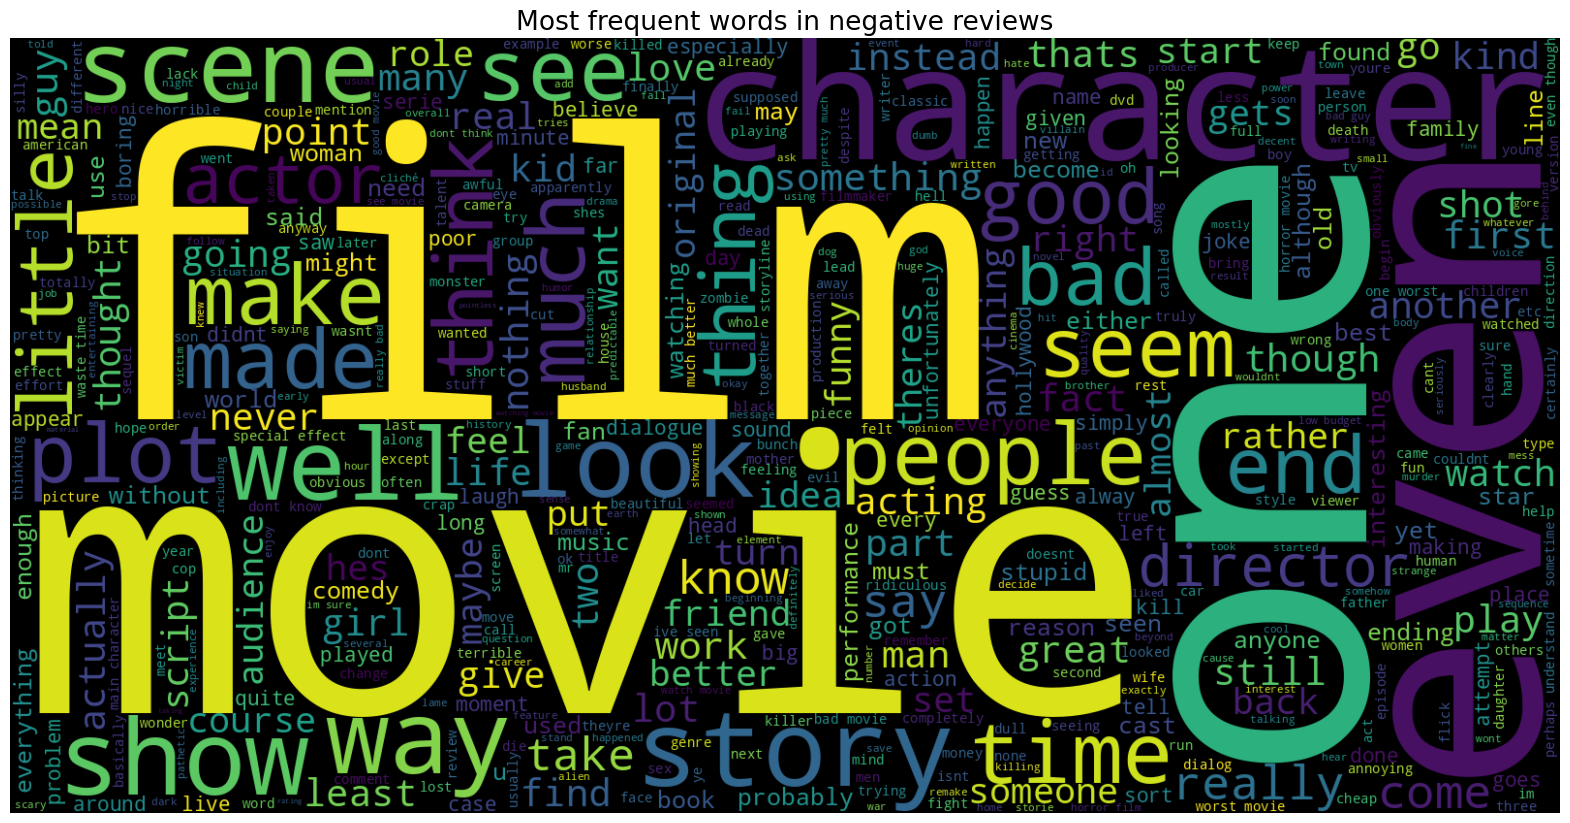

In [ ]:
text = ' '.join([word for word in neg_reviews['review']])
plt.figure(figsize=(20,15), facecolor='None')
wordcloud = WordCloud(max_words=500, width=1600, height=800).generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title('Most frequent words in negative reviews', fontsize = 19)
plt.show()

In [ ]:
count = Counter()
for text in neg_reviews['review'].values:
    for word in text.split():
        count[word] += 1
count.most_common(15)

[('movie', 47489),
 ('film', 35042),
 ('one', 24636),
 ('like', 21771),
 ('even', 14918),
 ('good', 14141),
 ('bad', 14068),
 ('would', 13633),
 ('really', 12220),
 ('time', 11494),
 ('see', 10567),
 ('dont', 10029),
 ('get', 9996),
 ('much', 9898),
 ('story', 9672)]

In [ ]:
neg_words = pd.DataFrame(count.most_common(15))
neg_words.columns = ['word', 'count']
neg_words.head()

,word,count
0,movie,47489
1,film,35042
2,one,24636
3,like,21771
4,even,14918


In [ ]:
px.bar(neg_words, x='count', y='word', title='Common words in negative reviews', color='word')


#**LSTM - Long Short-Term Memory**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input
from keras.layers import  Dropout
from keras.callbacks import EarlyStopping



model = Sequential()
model.add(Embedding(input_dim=5000, output_dim=128, input_shape=(200,)))
model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1, activation="sigmoid"))

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 200, 128)            │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 128)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 771,713 (2.94 MB)

 Trainable params: 771,713 (2.94 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

**Training the Model**

In [ ]:
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

Epoch 1/5


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


500/500 ━━━━━━━━━━━━━━━━━━━━ 140s 267ms/step - accuracy: 0.7732 - loss: 0.4759 - val_accuracy: 0.8604 - val_loss: 0.3546
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 131s 253ms/step - accuracy: 0.8793 - loss: 0.2994 - val_accuracy: 0.8735 - val_loss: 0.3006
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 146s 261ms/step - accuracy: 0.9075 - loss: 0.2360 - val_accuracy: 0.8763 - val_loss: 0.3068
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 138s 253ms/step - accuracy: 0.9231 - loss: 0.2039 - val_accuracy: 0.8716 - val_loss: 0.3397
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 141s 251ms/step - accuracy: 0.9321 - loss: 0.1788 - val_accuracy: 0.8681 - val_loss: 0.3435


**Model Evaluation**

In [ ]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 84ms/step - accuracy: 0.8682 - loss: 0.3267


[0.3290897607803345, 0.8705000281333923]

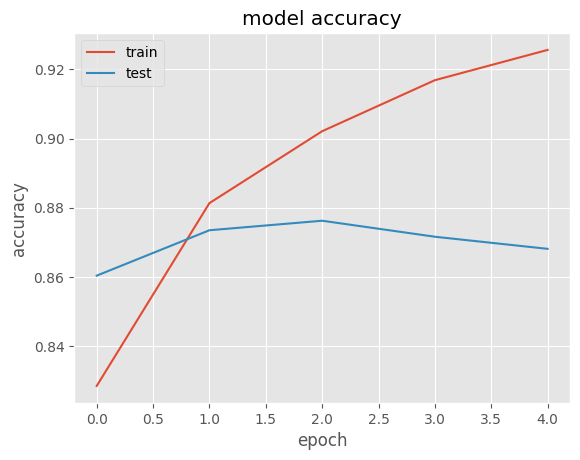

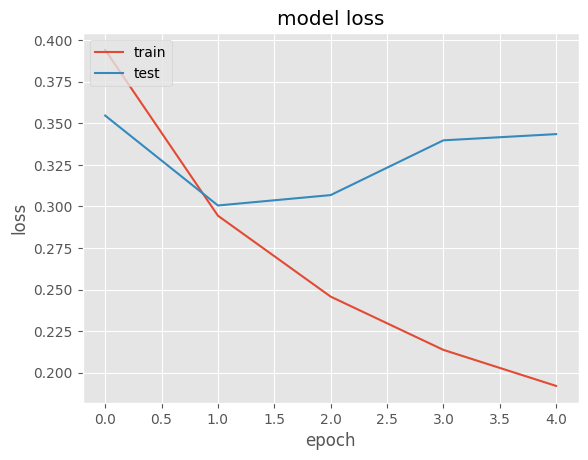

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

#**adding**  few lstm layers-stacked lstm

In [ ]:
model_2 = Sequential()
model_2.add(Embedding(input_dim=5000, output_dim=128, input_length=200,input_shape=(200,)))
model_2.add(LSTM(128,  dropout=0.2, recurrent_dropout=0.2,return_sequences=True))
model_2.add(LSTM(128,  dropout=0.2, recurrent_dropout=0.2,return_sequences=False))
model_2.add(Dense(1, activation="sigmoid"))


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model_2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [ ]:
model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 200, 128)            │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 200, 128)            │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 128)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 903,297 (3.45 MB)

 Trainable params: 903,297 (3.45 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_2.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

**Training the Model**

In [ ]:
history_2=model_2.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2,callbacks=[early_stopping])

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 280s 540ms/step - accuracy: 0.7810 - loss: 0.4530 - val_accuracy: 0.8139 - val_loss: 0.4151
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 310s 529ms/step - accuracy: 0.8770 - loss: 0.3122 - val_accuracy: 0.8756 - val_loss: 0.3018
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 344s 573ms/step - accuracy: 0.9078 - loss: 0.2410 - val_accuracy: 0.8775 - val_loss: 0.2951
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 275s 549ms/step - accuracy: 0.9210 - loss: 0.2100 - val_accuracy: 0.8794 - val_loss: 0.3031
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 322s 550ms/step - accuracy: 0.9334 - loss: 0.1779 - val_accuracy: 0.8764 - val_loss: 0.3097
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 323s 553ms/step - accuracy: 0.9492 - loss: 0.1450 - val_accuracy: 0.8754 - val_loss: 0.3336


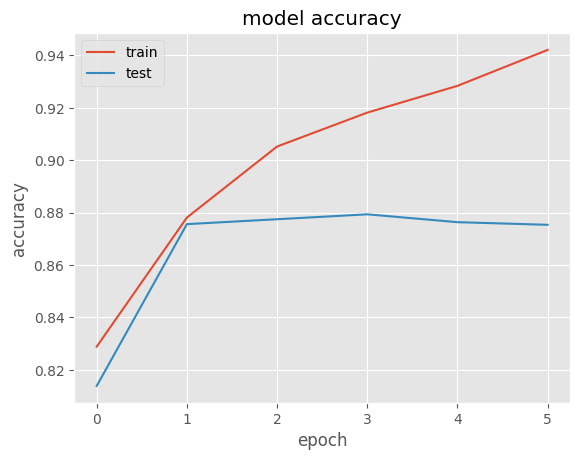

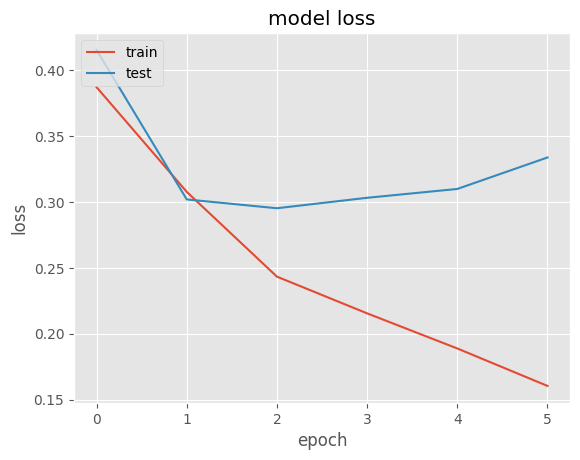

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_2.history['accuracy'])
plt.plot(history_2.history['val_accuracy'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

plt.plot(history_2.history['loss'])
plt.plot(history_2.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

#gru

In [ ]:
from keras.models import Sequential
from keras.layers import Embedding, GRU, Dense, Dropout
from keras.callbacks import EarlyStopping

model_3 = Sequential()
model_3.add(Embedding(input_dim=5000, output_dim=128, input_length=200, input_shape=(200,)))
model_3.add(GRU(128, dropout=0.2, recurrent_dropout=0.2, return_sequences=False))
model_3.add(Dense(1, activation="sigmoid"))


model_3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


model_3.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)              │ (None, 200, 128)            │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ (None, 128)                 │          99,072 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 739,201 (2.82 MB)

 Trainable params: 739,201 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

**Training the Model**

In [ ]:
history_3=model_3.fit(X_train, Y_train, epochs=5, batch_size=64, validation_split=0.2,callbacks=[early_stopping])

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 170s 336ms/step - accuracy: 0.6207 - loss: 7435073536.0000 - val_accuracy: 0.7005 - val_loss: 0.5812
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 201s 333ms/step - accuracy: 0.7394 - loss: 26894.5410 - val_accuracy: 0.6995 - val_loss: 0.5693
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 201s 330ms/step - accuracy: 0.7651 - loss: 3255603.7500 - val_accuracy: 0.6760 - val_loss: 0.5888
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 213s 352ms/step - accuracy: 0.6984 - loss: 525319045120.0000 - val_accuracy: 0.6505 - val_loss: 0.6147
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 191s 331ms/step - accuracy: 0.7178 - loss: 0.5410 - val_accuracy: 0.6571 - val_loss: 0.6121


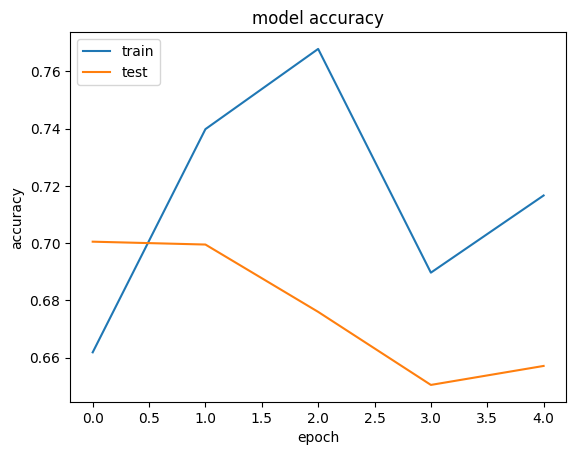

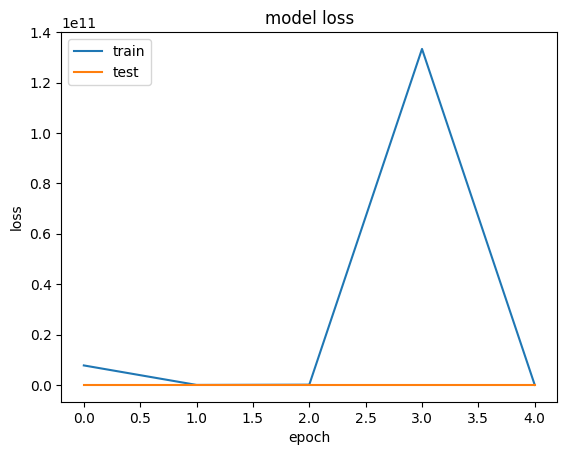

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_3.history['accuracy'])
plt.plot(history_3.history['val_accuracy'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

plt.plot(history_3.history['loss'])
plt.plot(history_3.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

# Transfer Learning on Rotten Tomato dataset from Kaggle

doing it on rotten tomato datset

In [ ]:
df=pd.read_csv("/content/data_rt.csv")

In [ ]:
df.head()

,reviews,labels
0,"simplistic , silly and tedious .",0
1,"it's so laddish and juvenile , only teenage bo...",0
2,exploitative and largely devoid of the depth o...,0
3,[garbus] discards the potential for pathologic...,0
4,a visually flashy but narratively opaque and e...,0


##eda

In [ ]:
df.shape

(10662, 2)

In [ ]:
df.head()

,reviews,labels
0,"simplistic , silly and tedious .",0
1,"it's so laddish and juvenile , only teenage bo...",0
2,exploitative and largely devoid of the depth o...,0
3,[garbus] discards the potential for pathologic...,0
4,a visually flashy but narratively opaque and e...,0


In [ ]:
df.tail()

,reviews,labels
10657,both exuberantly romantic and serenely melanch...,1
10658,mazel tov to a film about a family's joyous li...,1
10659,standing in the shadows of motown is the best ...,1
10660,it's nice to see piscopo again after all these...,1
10661,"provides a porthole into that noble , tremblin...",1


In [ ]:
review_counts = df["labels"].value_counts()
print(review_counts)

labels
0    5331
1    5331
Name: count, dtype: int64


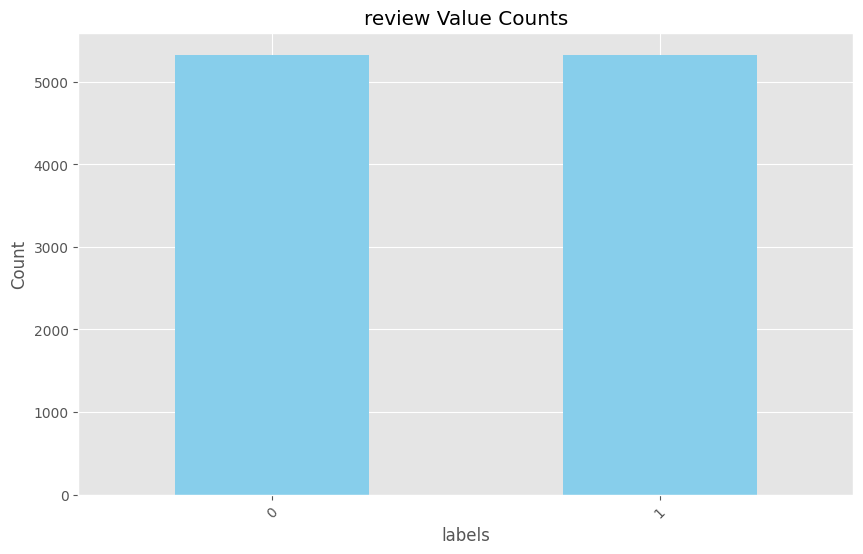

In [ ]:
plt.figure(figsize=(10, 6))
review_counts.plot(kind='bar', color='skyblue')
plt.title('review Value Counts')
plt.xlabel('labels')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

most freq words in pos review

In [ ]:
pos_reviews_new = df[df.labels ==1]
pos_reviews_new.head()

,reviews,labels
5331,rock destined 21st centurys new conan hes goin...,1
5332,gorgeously elaborate continuation lord rings t...,1
5333,effective tootepid biopic,1
5334,sometimes like go movies fun wasabi good place...,1
5335,emerges something rare issue movie thats hones...,1


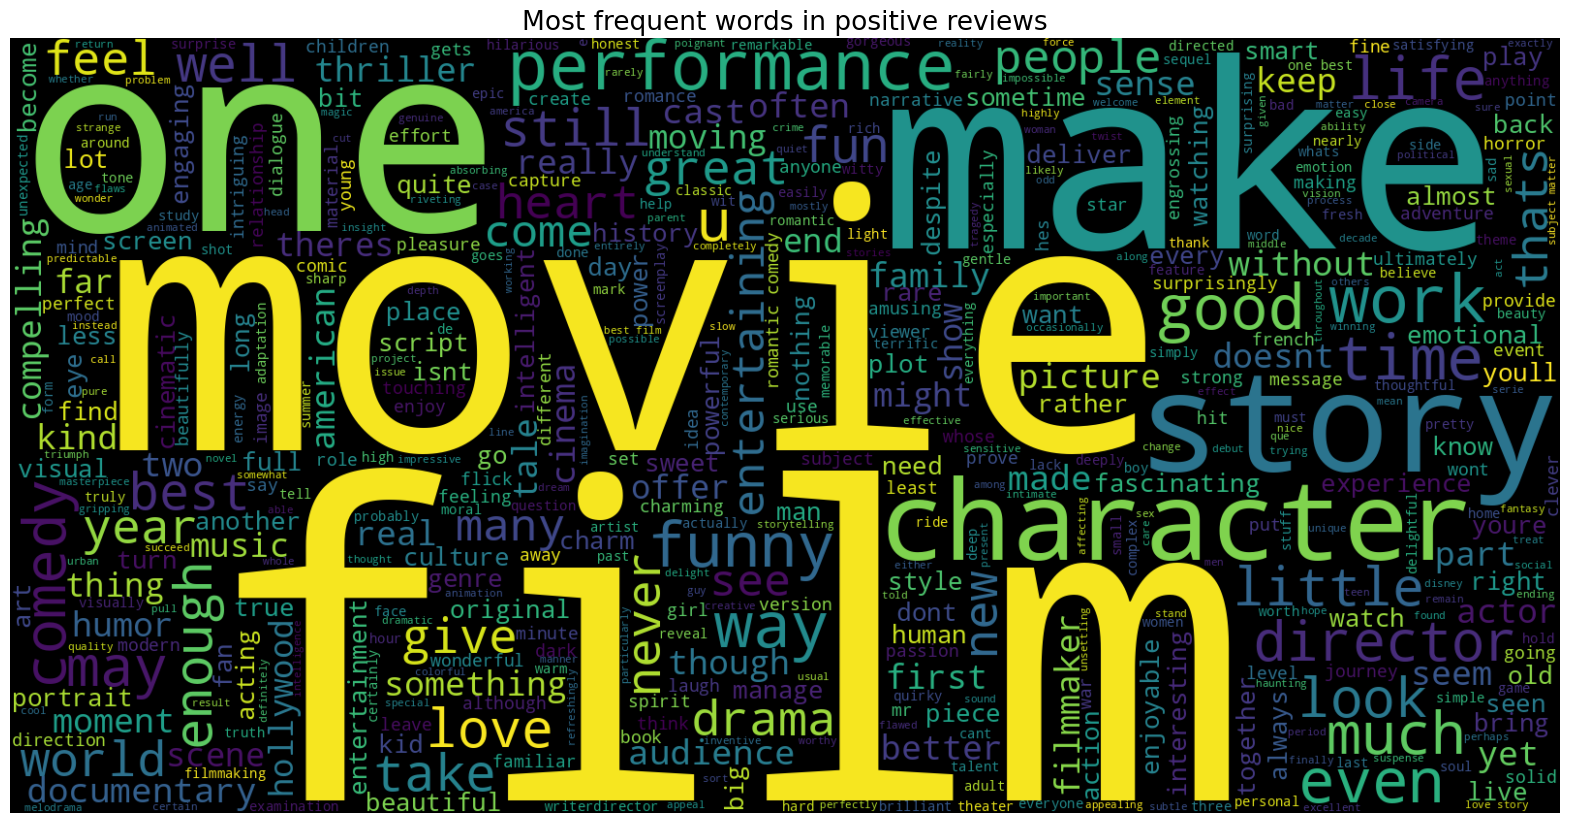

In [ ]:
text = ' '.join([word for word in pos_reviews_new['reviews']])
plt.figure(figsize=(20,15), facecolor='None')
wordcloud = WordCloud(max_words=500, width=1600, height=800).generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title('Most frequent words in positive reviews', fontsize = 19)
plt.show()

In [ ]:
from collections import Counter
count = Counter()
for text in pos_reviews_new['reviews'].values:
    for word in text.split():
        count[word] +=1
count.most_common(15)

[('film', 826),
 ('movie', 512),
 ('one', 366),
 ('like', 282),
 ('story', 256),
 ('good', 198),
 ('comedy', 193),
 ('films', 183),
 ('funny', 181),
 ('even', 180),
 ('best', 166),
 ('way', 164),
 ('characters', 161),
 ('time', 159),
 ('us', 156)]

In [ ]:
#creating df for it
pos_words = pd.DataFrame(count.most_common(15))
pos_words.columns = ['word', 'count']
pos_words.head()

,word,count
0,film,826
1,movie,512
2,one,366
3,like,282
4,story,256


In [ ]:
px.bar(pos_words, x='count', y='word', title='Common words in positive reviews', color='word')


same for neg words

In [ ]:
neg_reviews = df[df.labels == 0]
neg_reviews.head()

,reviews,labels
0,simplistic silly tedious,0
1,laddish juvenile teenage boys could possibly f...,0
2,exploitative largely devoid depth sophisticati...,0
3,garbus discards potential pathological study e...,0
4,visually flashy narratively opaque emotionally...,0


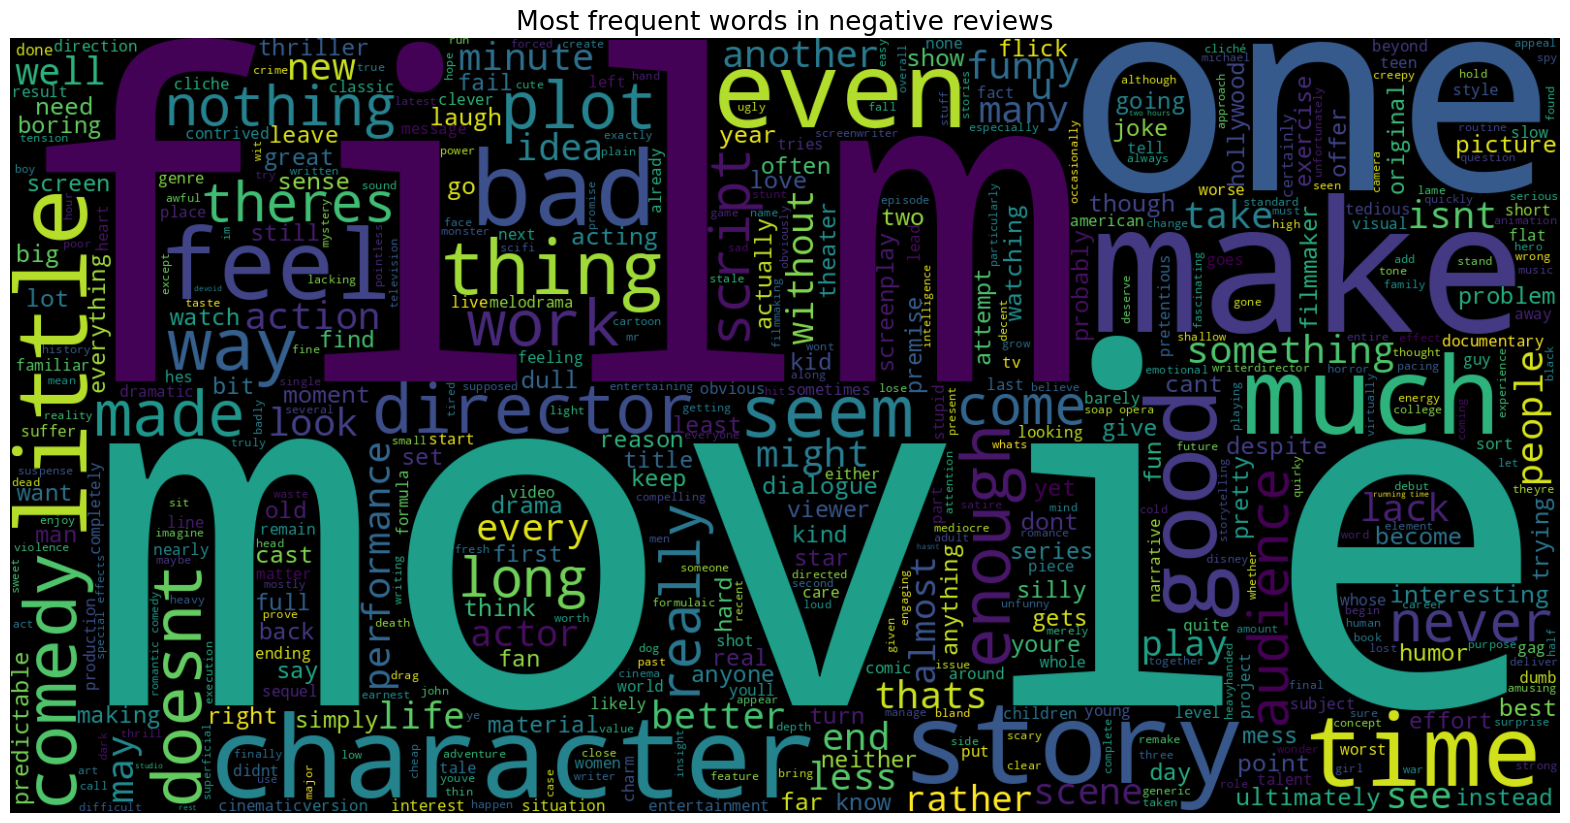

In [ ]:
text = ' '.join([word for word in neg_reviews['reviews']])
plt.figure(figsize=(20,15), facecolor='None')
wordcloud = WordCloud(max_words=500, width=1600, height=800).generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title('Most frequent words in negative reviews', fontsize = 19)
plt.show()

In [ ]:
count = Counter()
for text in neg_reviews['reviews'].values:
    for word in text.split():
        count[word] += 1
count.most_common(15)

[('movie', 758),
 ('film', 626),
 ('like', 439),
 ('one', 361),
 ('much', 232),
 ('story', 221),
 ('bad', 207),
 ('even', 202),
 ('time', 182),
 ('characters', 179),
 ('good', 179),
 ('little', 173),
 ('comedy', 166),
 ('doesnt', 153),
 ('never', 152)]

In [ ]:
neg_words = pd.DataFrame(count.most_common(15))
neg_words.columns = ['word', 'count']
neg_words.head()

,word,count
0,movie,758
1,film,626
2,like,439
3,one,361
4,much,232


In [ ]:
px.bar(neg_words, x='count', y='word', title='Common words in negative reviews', color='word')


In [ ]:
# split data into training data and test data
train_data_rt, test_data_rt = train_test_split(df, test_size=0.2, random_state=42)

In [ ]:
print(train_data_rt.shape)
print(test_data_rt.shape)

(8529, 2)
(2133, 2)


##**Data Preprocessing**

In [ ]:
def data_processing(text):
    text = text.lower()
    text = re.sub('<br />', '', text)
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'\@w+|\#','', text)
    text = re.sub(r'[^\w\s]','', text)
    text_tokens = word_tokenize(text)
    filtered_text = [w for w in text_tokens if not w in stop_words]
    return " ".join(filtered_text)

In [ ]:
df.reviews = df['reviews'].apply(data_processing)

In [ ]:
stemmer = PorterStemmer()
def stemming(data):
    text = [stemmer.stem(word) for word in data]
    return data

In [ ]:
df.review = df['reviews'].apply(lambda x: stemming(x))

In [ ]:
df

,reviews,labels
0,simplistic silly tedious,0
1,laddish juvenile teenage boys could possibly f...,0
2,exploitative largely devoid depth sophisticati...,0
3,garbus discards potential pathological study e...,0
4,visually flashy narratively opaque emotionally...,0
...,...,...
10657,exuberantly romantic serenely melancholy time ...,1
10658,mazel tov film familys joyous life acting yidd...,1
10659,standing shadows motown best kind documentary ...,1
10660,nice see piscopo years chaykin headly priceless,1


In [ ]:
x_rt = df['reviews']
y_rt = df['labels']

In [ ]:
x_train_rt, x_test_rt, y_train_rt, y_test_rt = train_test_split(x_rt, y_rt, test_size=0.2, random_state=42)


In [ ]:
# Tokenize text data
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(train_data_rt["reviews"])
x_train_rt = pad_sequences(tokenizer.texts_to_sequences(train_data_rt["reviews"]), maxlen=200)
x_test_rt = pad_sequences(tokenizer.texts_to_sequences(test_data_rt["reviews"]), maxlen=200)

In [ ]:
y_train_rt = train_data_rt["labels"]
y_test_rt = test_data_rt["labels"]

**LSTM - Long Short-Term Memory**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input



model_rt = Sequential()
model_rt.add(Embedding(input_dim=5000, output_dim=128, input_shape=(200,)))
model_rt.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
model_rt.add(Dense(1, activation="sigmoid"))

model_rt.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:93: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)              │ (None, 200, 128)            │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 128)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 771,713 (2.94 MB)

 Trainable params: 771,713 (2.94 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# compile the model
model_rt.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

**Training the Model**

In [ ]:
history_rt=model_rt.fit(x_train_rt, y_train_rt, epochs=5, batch_size=64, validation_split=0.2)

Epoch 1/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 38s 335ms/step - accuracy: 0.5467 - loss: 0.6799 - val_accuracy: 0.7122 - val_loss: 0.5618
Epoch 2/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 44s 363ms/step - accuracy: 0.8159 - loss: 0.4193 - val_accuracy: 0.7321 - val_loss: 0.5593
Epoch 3/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 46s 408ms/step - accuracy: 0.8889 - loss: 0.2640 - val_accuracy: 0.7157 - val_loss: 0.6368
Epoch 4/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 37s 347ms/step - accuracy: 0.9320 - loss: 0.1818 - val_accuracy: 0.7116 - val_loss: 0.7629
Epoch 5/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 42s 354ms/step - accuracy: 0.9511 - loss: 0.1320 - val_accuracy: 0.7063 - val_loss: 1.0677


**Model Evaluation**

In [ ]:
loss, accuracy = model_rt.evaluate(x_test_rt, y_test_rt)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

67/67 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accuracy: 0.7290 - loss: 0.8925
Test Loss: 0.9620265960693359
Test Accuracy: 0.713549017906189


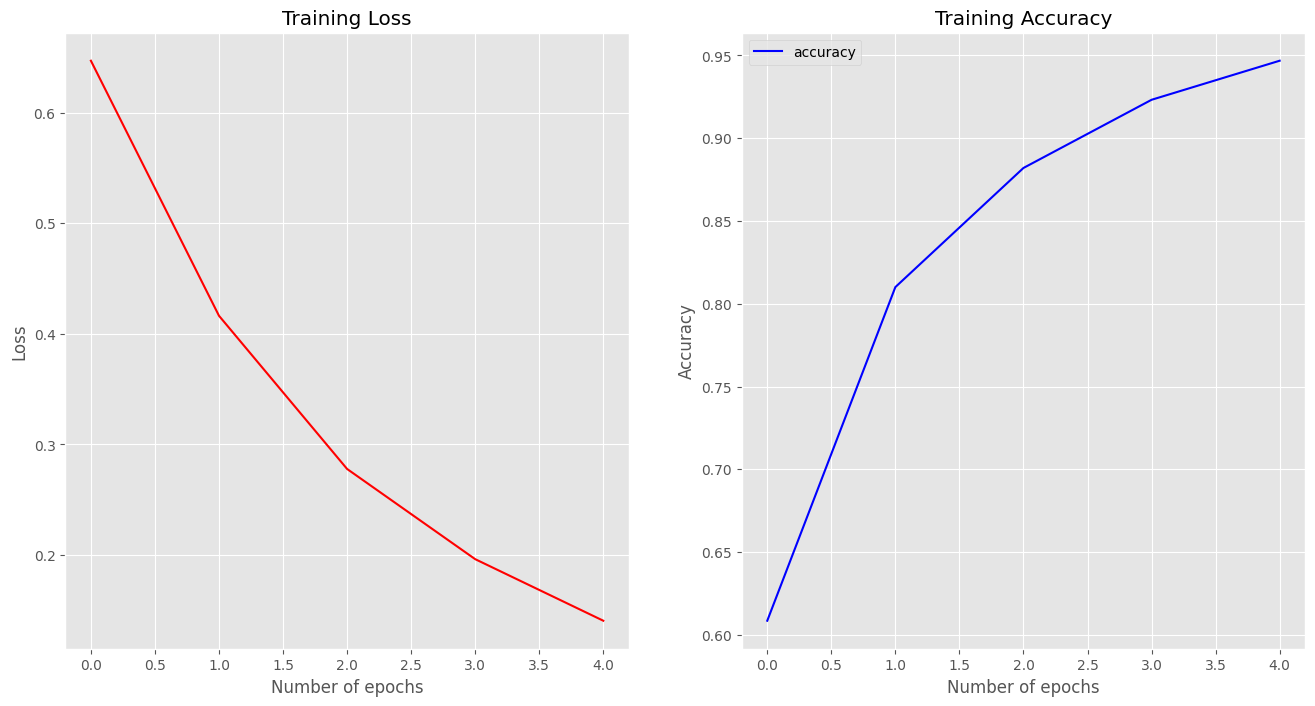

In [ ]:
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.plot(history_rt.history['loss'], color='r', label='loss')
plt.title('Training Loss')
plt.xlabel("Number of epochs")
plt.ylabel("Loss")
plt.subplot(1,2,2)
plt.plot(history_rt.history['accuracy'], color='b', label='accuracy')
plt.title('Training Accuracy')
plt.xlabel("Number of epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#Making Predictions




In [ ]:

def predict_sentiment(review):

  sequence = tokenizer.texts_to_sequences([review])
  padded_sequence = pad_sequences(sequence, maxlen=200)
  prediction = model.predict(padded_sequence)
  sentiment = "positive" if prediction[0][0] > 0.5 else "negative" #threshold of 0.5
  return sentiment


In [ ]:
# example usage
new_review = "This movie was fantastic. I loved it."
sentiment = predict_sentiment(new_review)
print(f"The sentiment of the review is: {sentiment}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step
The sentiment of the review is: positive


In [ ]:

new_review = "This movie was not that good"
sentiment = predict_sentiment(new_review)
print(f"The sentiment of the review is: {sentiment}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
The sentiment of the review is: negative


In [ ]:
# example usage
new_review = "This movie was ok but not that good."
sentiment = predict_sentiment(new_review)
print(f"The sentiment of the review is: {sentiment}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
The sentiment of the review is: negative


#decreasing target words by 0.5

In [ ]:
#Tokenization
tokenizer = Tokenizer(num_words=2500)
tokenizer.fit_on_texts(X_train)
x_train_seq = tokenizer.texts_to_sequences(X_train)
x_test_seq = tokenizer.texts_to_sequences(X_test)

In [ ]:
#Padding sequences
x_train = pad_sequences(x_train_seq, maxlen=200)
x_test = pad_sequences(x_test_seq, maxlen=200)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input
from keras.layers import  Dropout
from keras.callbacks import EarlyStopping



model = Sequential()
model.add(Embedding(input_dim=2500, output_dim=128, input_shape=(200,)))
model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1, activation="sigmoid"))

model.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 200, 128)            │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 128)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 451,713 (1.72 MB)

 Trainable params: 451,713 (1.72 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

**Training the Model**

In [ ]:
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 146s 275ms/step - accuracy: 0.7684 - loss: 0.4724 - val_accuracy: 0.8581 - val_loss: 0.3324
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 201s 287ms/step - accuracy: 0.8738 - loss: 0.3100 - val_accuracy: 0.8668 - val_loss: 0.3228
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 205s 292ms/step - accuracy: 0.8882 - loss: 0.2764 - val_accuracy: 0.8712 - val_loss: 0.3262
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 129s 258ms/step - accuracy: 0.9008 - loss: 0.2487 - val_accuracy: 0.8724 - val_loss: 0.3211
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 252ms/step - accuracy: 0.8930 - loss: 0.2637 - val_accuracy: 0.8404 - val_loss: 0.3797
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 133s 266ms/step - accuracy: 0.9023 - loss: 0.2488 - val_accuracy: 0.8659 - val_loss: 0.3348
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 148s 278ms/step - accuracy: 0.9190 - loss: 0.2111 - val_accuracy: 0.8646 - val_loss: 0.3497
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 141s 277ms/step - accuracy: 0.9279 -

**Model Evaluation**

In [ ]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/step - accuracy: 0.8608 - loss: 0.3486


[0.34744346141815186, 0.8633000254631042]

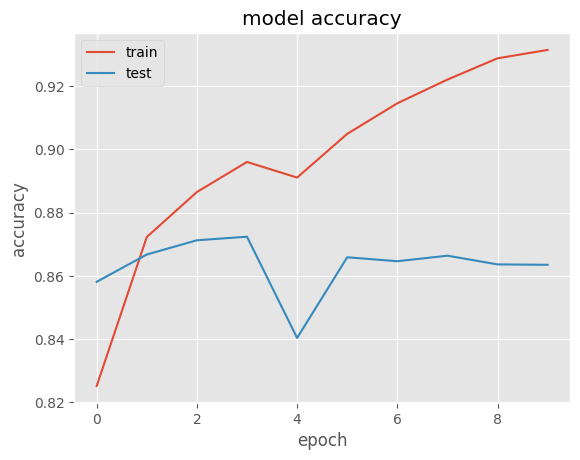

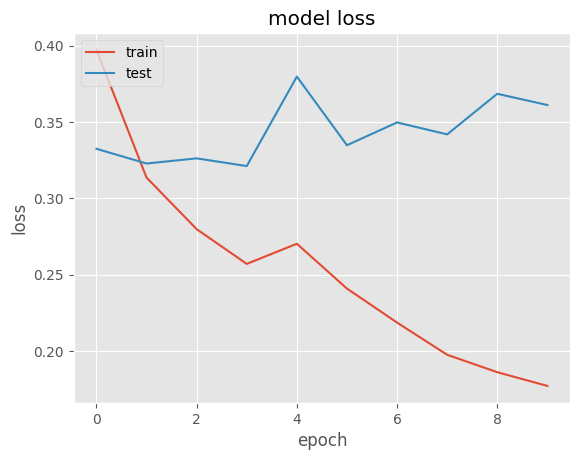

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

#increasing target words by 0.5

In [ ]:
#Tokenization
tokenizer_2 = Tokenizer(num_words=1000)
tokenizer_2.fit_on_texts(X_train)
x_train_seq_2 = tokenizer_2.texts_to_sequences(X_train)
x_test_seq_2 = tokenizer_2.texts_to_sequences(X_test)

In [ ]:
#Padding sequences
x_train_2 = pad_sequences(x_train_seq_2, maxlen=200)
x_test_2 = pad_sequences(x_test_seq_2, maxlen=200)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input
from keras.layers import  Dropout
from keras.callbacks import EarlyStopping



model_new = Sequential()
model_new.add(Embedding(input_dim=1000, output_dim=128, input_shape=(200,)))
model_new.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
model_new.add(Dense(1, activation="sigmoid"))

model_new.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 200, 128)            │         128,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 128)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 259,713 (1014.50 KB)

 Trainable params: 259,713 (1014.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_new.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

**Training the Model**

In [ ]:
history_new = model_new.fit(x_train_2, y_train, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 133s 263ms/step - accuracy: 0.7541 - loss: 0.5050 - val_accuracy: 0.8455 - val_loss: 0.3570
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 137s 253ms/step - accuracy: 0.8468 - loss: 0.3728 - val_accuracy: 0.7964 - val_loss: 0.4380
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 129s 258ms/step - accuracy: 0.8519 - loss: 0.3512 - val_accuracy: 0.8529 - val_loss: 0.3482
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 141s 256ms/step - accuracy: 0.8670 - loss: 0.3242 - val_accuracy: 0.8451 - val_loss: 0.3512
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 256ms/step - accuracy: 0.8710 - loss: 0.3097 - val_accuracy: 0.8480 - val_loss: 0.3496
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 143s 258ms/step - accuracy: 0.8745 - loss: 0.3002 - val_accuracy: 0.8528 - val_loss: 0.3419
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 140s 254ms/step - accuracy: 0.8769 - loss: 0.2972 - val_accuracy: 0.8491 - val_loss: 0.3465
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 255ms/step - accuracy: 0.8811 -

**Model Evaluation**

In [ ]:
model_new.evaluate(x_test_2,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/step - accuracy: 0.8440 - loss: 0.3506


[0.3490269184112549, 0.8464000225067139]

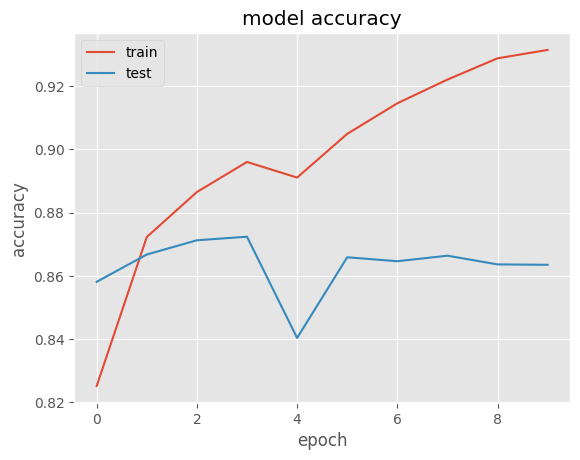

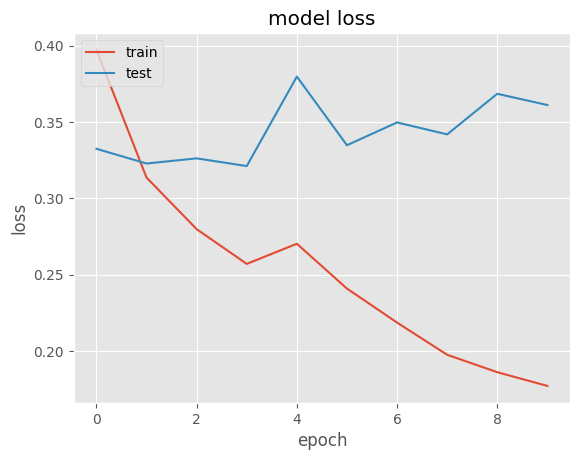

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

#biLstm

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional
from keras.layers import Dropout
from keras.callbacks import EarlyStopping

In [ ]:
model = Sequential()
model.add(Embedding(input_dim=5000, output_dim=128,input_shape=(200,)))
model.add(Bidirectional(LSTM(128, dropout=0.2, recurrent_dropout=0.2)))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))


model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)              │ (None, 200, 128)            │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 256)                 │         263,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 903,425 (3.45 MB)

 Trainable params: 903,425 (3.45 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2, callbacks=[early_stop])


Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 468s 924ms/step - accuracy: 0.7362 - loss: 0.4902 - val_accuracy: 0.8589 - val_loss: 0.3324
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 498s 917ms/step - accuracy: 0.8922 - loss: 0.2765 - val_accuracy: 0.8755 - val_loss: 0.3002
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 507s 927ms/step - accuracy: 0.9066 - loss: 0.2421 - val_accuracy: 0.8733 - val_loss: 0.3055
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 494s 912ms/step - accuracy: 0.9209 - loss: 0.2081 - val_accuracy: 0.8776 - val_loss: 0.3180
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 452s 905ms/step - accuracy: 0.9248 - loss: 0.1934 - val_accuracy: 0.8725 - val_loss: 0.3434


In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f'Test Accuracy: {test_accuracy:.2f}')


313/313 ━━━━━━━━━━━━━━━━━━━━ 60s 191ms/step - accuracy: 0.8854 - loss: 0.2818
Test Accuracy: 0.88


In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


#hyperparameter tuning using randomsearch

In [9]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.2 MB/s eta 0:00:00


In [10]:
import keras_tuner as kt
from tensorflow.keras.optimizers import Adagrad

In [11]:
def build_model(hp):
    model_hp = Sequential()
    # Embedding layer with hyperparameter tuning for output_dim
    model_hp.add(Embedding(input_dim=5000,
                        output_dim=hp.Int('embedding_dim', min_value=32, max_value=256, step=32),
                        input_length=200))

    # LSTM layer with hyperparameter tuning for units, dropout, and recurrent_dropout
    model_hp.add(LSTM(hp.Int('lstm_units', min_value=64, max_value=256, step=64),
                   dropout=hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1),
                   recurrent_dropout=hp.Float('recurrent_dropout', min_value=0.1, max_value=0.5, step=0.1)))

    # Dense layer
    model_hp.add(Dense(1, activation='sigmoid'))

    model_hp.compile(optimizer=hp.Choice('optimizer', values=['Adagrad', 'rmsprop']),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model_hp

In [12]:
#Initialize Keras Tuner with Random Search
tuner = kt.RandomSearch(build_model,
                        objective='val_accuracy',
                        max_trials=10,  #models to try
                        executions_per_trial=3,  #trials to run for each model
                        directory='my_dir',
                        project_name='lstm_tuning')


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [13]:
# Early stopping callback to prevent overfitting
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3)


In [14]:

from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [38]:
# Convert y_train to NumPy array if it's a Pandas Series
y_train = y_train.to_numpy()


In [ ]:

for train_index, val_index in kf.split(x_train):
    x_train_fold, x_val_fold = x_train[train_index], x_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]  # Use NumPy indexing
    # Perform hyperparameter search for each fold
    tuner.search(x_train_fold, y_train_fold, epochs=5, batch_size=64, validation_data=(x_val_fold, y_val_fold), callbacks=[early_stop])


Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 649s 1s/step - accuracy: 0.5179 - loss: 0.6929 - val_accuracy: 0.5226 - val_loss: 0.6928
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 656s 1s/step - accuracy: 0.5272 - loss: 0.6927 - val_accuracy: 0.5206 - val_loss: 0.6928
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 621s 1s/step - accuracy: 0.5216 - loss: 0.6927 - val_accuracy: 0.5215 - val_loss: 0.6927
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 668s 1s/step - accuracy: 0.5271 - loss: 0.6926 - val_accuracy: 0.5291 - val_loss: 0.6926
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 640s 1s/step - accuracy: 0.5313 - loss: 0.6926 - val_accuracy: 0.5294 - val_loss: 0.6925
251/500 ━━━━━━━━━━━━━━━━━━━━ 4:46 1s/step - accuracy: 0.5017 - loss: 0.6932

In [ ]:
# Get the best hyperparameters and model
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

In [ ]:
 best_model = tuner.hypermodel.build(best_hp)

In [ ]:
# Train the best model
history_hp = best_model.fit(x_train, y_train, epochs=8, batch_size=64, validation_split=0.2)


In [ ]:
# Evaluate the best model on the test set
best_model.evaluate(x_test, y_test)
